In [1]:
from matplotlib import pyplot as plt
import pandas as pd
from surrogate import SurrogateAutoMLModel
from surrogate import SurrogateTabPFN
from tabpfn_extensions.interpretability.shap import *
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

df = pd.read_csv('water_tank_exps.csv')

In [2]:
#amodel = SurrogateAutoMLModel(time_budget=60, verbose=1, n_jobs=-1)
#tmodel = SurrogateTabPFN(time_budget=None)amodel.train(df[['action_mode', 'tg_threshold', 'water_tank_size']], df['urbac'])
#tmodel.train(df[['action_mode', 'tg_threshold', 'water_tank_size']], df['urbac'])
#
#amodel.save_model('amodel.pkl')
#tmodel.save_model('tmodel.pkl')
amodel = SurrogateAutoMLModel(time_budget=60, verbose=1, n_jobs=-1)
tmodel = SurrogateTabPFN(time_budget=None)

In [3]:
amodel.load_model('amodel.pkl'), tmodel.load_model('tmodel.pkl')

(AutoML(append_log=False, auto_augment=True, custom_hp={},
        cv_score_agg_func=None, early_stop=False, ensemble=False,
        estimator_list='auto', eval_method='auto', fit_kwargs_by_estimator={},
        force_cancel=False, free_mem_ratio=0, hpo_method='auto',
        keep_search_state=False, learner_selector='sample', log_file_name='',
        log_training_metric=False, log_type='better', max_iter=None,
        mem_thres=4294967296, metric='auto', metric_constraints=[],
        min_sample_size=10000, mlflow_logging=True, model_history=False,
        n_concurrent_trials=1, n_jobs=-1, n_splits=5, pred_time_limit=inf,
        preserve_checkpoint=True, retrain_full=True, ...),
 TabPFNRegressor())

In [4]:
tshap_values=get_shap_values(tmodel, df[['action_mode', 'tg_threshold', 'water_tank_size']])
ashap_values=get_shap_values(amodel, df[['action_mode', 'tg_threshold', 'water_tank_size']])

ExactExplainer explainer: 401it [05:10,  1.26it/s]                         
ExactExplainer explainer: 401it [00:26,  9.55it/s]                         


In [5]:
var_dict = {
    'action_mode': 'SI',
    'tg_threshold': "T$_{\\mathrm{g}}$ threshold [°C]",
    'water_tank_size': "RWT size [mm]"
}

def plot_size_legend(smax, ax, title, loc=False):
    # 添加大小图例
    sizes = [ smax* 0.1, smax]
    labels = [f"{size}" for size in sizes]
    handles = [
        plt.scatter([], [], s=size, color="gray", label=label) for size, label in zip(sizes, labels)
    ]
    
    if title == 'RWT size [mm]':
        loc = "upper right" if not loc else loc
        ncol = 2
    else:
        loc = "best"
        ncol = 1
    
    legend = ax.legend(
        handles=handles,
        title=title,
        loc=loc,
        scatterpoints=1,
        frameon=True,
        ncol=ncol
    )
    ax.add_artist(legend)
    
def plot_bar_labels(ax, bars, labels):
    for bar, label in zip(bars, labels):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label,
            ha="center",
            va="bottom",
        )

def plot_raw(df, ax):
    p = ax.scatter(df['action_mode'], df['tg_threshold'], c=df['urbac'], 
                   #cmap='viridis', 
                   cmap=plt.get_cmap("rainbow"),
                   s=df['water_tank_size'], alpha=0.5, linewidths=0.5, edgecolors='k')
    ax.set_ylim(df['tg_threshold'].min()-1, df['tg_threshold'].max()+12)
    cbar = plt.colorbar(p)

    cbar.set_label('AC flux [W/m$^2$]')
    #ax.legend(['Water tank size'], loc='upper right')
    plot_size_legend(df['water_tank_size'].max().round(0), ax, 'RWT size [mm]')

    ax.set_xlabel('SI')
    ax.set_ylabel('T$_{\\mathrm{g}}$ threshold [°C]')
    ax.grid(linestyle="--", color="gray", linewidth=0.5, zorder=0, alpha=0.5)
    
def plot_surrogate_performance(df, ax):
    df_plot = df[['flod', 'model', 'MAE', 'RMSE']].melt(id_vars=['flod', 'model'], value_vars=['MAE', 'RMSE'])
    cmap = plt.get_cmap("rainbow", 2)  
    palette = [cmap(i) for i in range(cmap.N)] 
    sns.barplot(x='variable', y='value', hue='model', data=df_plot, ax=ax, ci='sd', 
                palette=palette, alpha=0.65, linewidth=1, edgecolor='k')
    ax.legend(frameon=False)
    #plot_bar_labels(ax, ax.patches, df_plot['value'].round(2))

def plot_sactter_shap(shap_values, xvar, cvar, svar, ax, loc=False):
    # or you need more flexible customization
    scatter = ax.scatter(
        shap_values[:, xvar].data,
        shap_values[:, xvar].values,
        c=shap_values[:, cvar].data,
        #smarker="^",
        s=shap_values[:, svar].data,
        cmap=plt.get_cmap("rainbow"),
        rasterized=True,
        zorder=5,
        alpha=0.5,
        linewidths=0.5,
        edgecolors="k",
    )

    cbar = plt.colorbar(scatter, format="%2.1f")
    cbar.set_label(var_dict[cvar])
    #cbar.outline.set_visible(False)
    smax = max(shap_values[:, svar].data).round(0) 
    plot_size_legend(smax, ax, var_dict[svar], loc=loc)

    ax.set_xlabel(var_dict[xvar])
    ax.set_ylabel(f"SHAP value for \n {var_dict[xvar].split(' [')[0]}")

    ax.grid(linestyle="--", color="gray", linewidth=0.5, zorder=0, alpha=0.5)
    
def plot_mean_shap_values(tshap_values, ashap_values, ax):
    
    df_shap1 = pd.DataFrame()
    df_shap1['feature'] = ['action_mode', 'tg_threshold', 'water_tank_size']
    df_shap1['shap_value'] = tshap_values.abs.mean(axis=0).values
    df_shap1['model'] = 'TabPFN'
    
    df_shap2 = pd.DataFrame()
    df_shap2['feature'] = ['action_mode', 'tg_threshold', 'water_tank_size']
    df_shap2['shap_value'] = ashap_values.abs.mean(axis=0).values
    df_shap2['model'] = 'AutoML'
    
    df_shap = pd.concat([df_shap2, df_shap1]).rename(columns={'shap_value': 'Mean |SHAP value|'}).replace(var_dict)
    
    display(df_shap)
    
    cmap = plt.get_cmap("rainbow", 2)  
    palette = [cmap(i) for i in range(cmap.N)] 
    p = sns.barplot(x='Mean |SHAP value|', y='feature', hue='model', data=df_shap, 
                    linewidth=1, edgecolor='k',
                    ax=ax, palette=palette, alpha=0.65)
    
    #plot_bar_labels(ax, ax.patches, df_shap['Mean |SHAP value|'].round(2))
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[4:6], labels=labels[4:6], frameon=False)
    

,flod,MAE,RMSE,R2,MAPE
model,,,,,
AutoML,4.5,292.208367,465.311884,0.973726,0.001527
TabPFN,4.5,64.996719,212.050914,0.985961,0.000339


,flod,MAE,RMSE,R2,MAPE
model,,,,,
AutoML,3.02765,76.365474,196.795748,0.022711,0.000398
TabPFN,3.02765,57.790174,310.953002,0.029465,0.000303


,feature,Mean |SHAP value|,model
0,SI,201.170868,AutoML
1,T$_{\mathrm{g}}$ threshold [°C],2451.961205,AutoML
2,RWT size [mm],799.075324,AutoML
0,SI,310.657995,TabPFN
1,T$_{\mathrm{g}}$ threshold [°C],2662.474909,TabPFN
2,RWT size [mm],711.280352,TabPFN


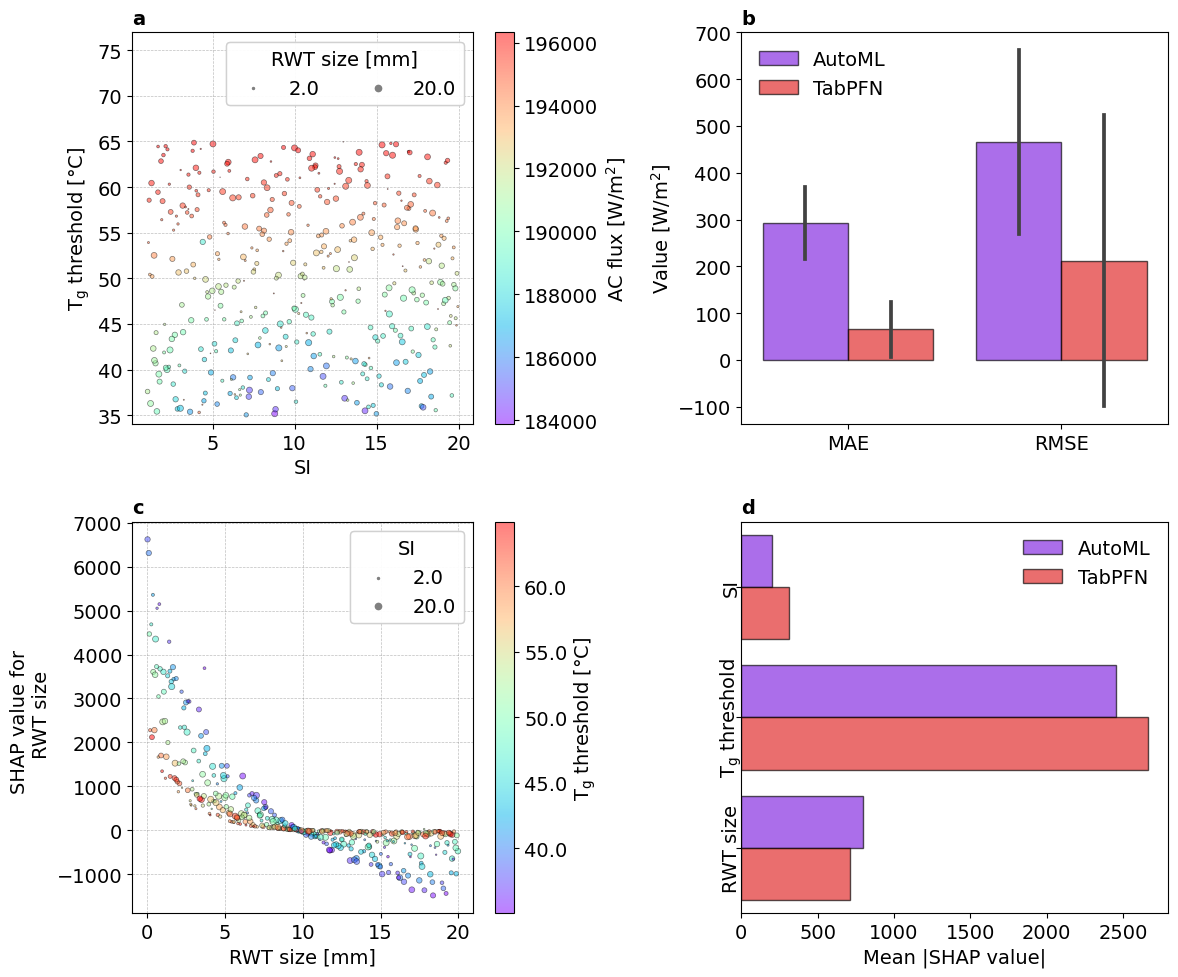

In [6]:
fig, axs = plt.subplots(tight_layout=True, figsize=(12, 10), ncols=2, nrows=2)
axs = axs.flatten()

plot_raw(df, axs[0])
df_p = pd.read_csv('surrogate_compare_res.csv')
display(df_p.groupby('model').mean())
display(df_p.groupby('model').std())
plot_surrogate_performance(df_p, axs[1])
axs[1].set_xlabel('')
axs[1].set_ylabel('Value [W/m$^2$]')

#plot_sactter_shap(tshap_values, 'action_mode', 'tg_threshold', 'water_tank_size', axs[2])
plot_sactter_shap(tshap_values, 'water_tank_size', 'tg_threshold', 'action_mode', axs[2])

plot_mean_shap_values(tshap_values, ashap_values, axs[3])
labels = [  i.get_text().split(" [")[0]  for i in axs[3].get_yticklabels()]
axs[3].set_yticklabels(labels, rotation=90, ha='center', va='center')
axs[3].set_ylabel('')

titles = ['a', 'b', 'c', 'd']
for ax, title in zip(axs, titles):
    ax.set_title(title, loc='left', fontsize=14, fontweight='bold')

plt.savefig('../data/figs/water_tank_exps.pdf', dpi=300, bbox_inches='tight')
plt.show()

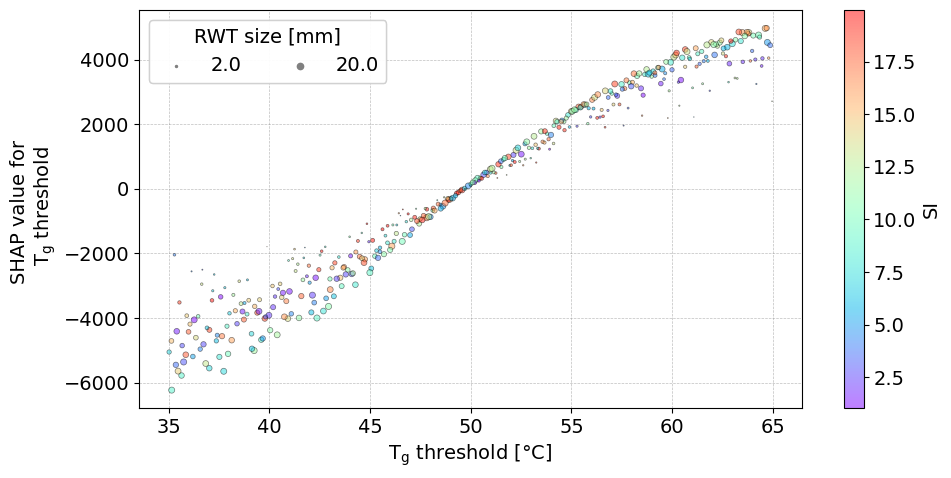

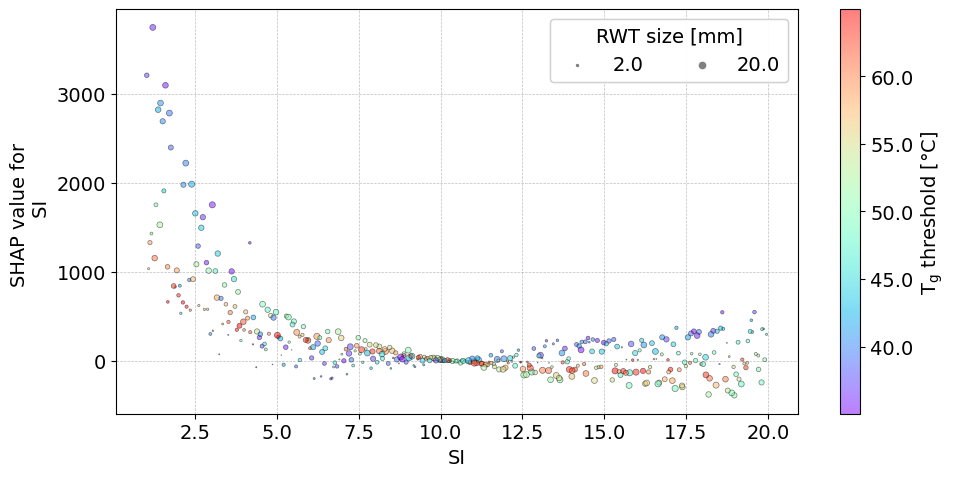

In [7]:
fig, axs = plt.subplots(tight_layout=True, figsize=(10, 5))
plot_sactter_shap(tshap_values, 'tg_threshold', 'action_mode',  'water_tank_size', axs, loc='best')
plt.savefig('../data/figs/water_tank_exps_shap_tg.pdf', dpi=300, bbox_inches='tight')

fig, axs = plt.subplots(tight_layout=True, figsize=(10, 5))
plot_sactter_shap(tshap_values, 'action_mode', 'tg_threshold', 'water_tank_size', axs)
plt.savefig('../data/figs/water_tank_exps_shap_SI.pdf', dpi=300, bbox_inches='tight')